# Modern Time Series Forecasting with Python
# Foundation Models

Marco Zanotti

In [ ]:
import sys
sys.path.insert(0, '../../src/Python/utils')
from utils import load_data 
import polars as pl
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mse, rmse 

# Introduction

In recent years, advancements in Neural Networks (NNs), particularly transformer-based models, have gained attention in time series forecasting. Building on work from other domains, research has grown rapidly in applying NNs to time series tasks. The main appeal comes from their ability to automatically extract meaningful representations from raw data, enabling them to capture complex nonlinear relationships in temporal dependencies.  

## Transformers and Attention Mechanisms

One of the most influential developments in deep learning has been the transformer architecture, introduced in "Attention Is All You Need" (Vaswani et al. 2017). Unlike traditional recurrent neural networks (RNNs) or long short-term memory (LSTM) networks, transformers process entire input sequences in parallel rather than sequentially. This eliminates the need for step-by-step recurrence, making them more scalable and efficient for large datasets.

The key innovation in transformers is the self-attention mechanism, which allows the model to weigh the importance of different input elements, even when they are far apart in a sequence. This makes transformers particularly effective for capturing long-range dependencies, a crucial advantage in domains like natural language processing (NLP) and time series forecasting. By leveraging multiple layers of self-attention and feed-forward networks, transformers learn complex hierarchical representations of data, making them powerful tools for various sequential tasks.

## Foundation Models and Their Impact

Foundation models, including large language models (LLMs) in natural language processing, have transformed AI by achieving state-of-the-art performance across diverse applications. These models leverage extensive datasets to build generalized representations, allowing them to perform well in a zero-shot fashion—making predictions without being specifically trained on a particular dataset. This paradigm eliminates the need to develop, implement, and train task-specific models for each use case.

The concept of foundation models gained prominence with BERT and GPT, but it was GPT-3 that demonstrated their full potential. Unlike earlier models that required task-specific supervised learning, foundation models follow a semi-supervised pre-training framework, where they first learn general patterns from vast amounts of unlabeled data and then adapt to specific tasks through fine-tuning.

While this approach revolutionized NLP, it has since been extended to other domains. In computer vision, models like Vision Transformers have applied transformer-based architectures to image processing. In scientific applications, foundation models such as AlphaFold have significantly advanced protein structure prediction.

Given the success of foundation models in natural language processing and computer vision, researchers have explored their application in time series forecasting. A notable early work demonstrated that the N-BEATS model could be pre-trained to enable zero-shot forecasting.

## Potential advantages

Foundation models offer key benefits over traditional task-specific approaches in time series forecasting. While this technology remains in early stages, its advantages include:

- Ease of use: Foundation models are pre-trained on large-scale datasets, allowing direct application to new datasets without extensive training.  

- Lower computational requirements: They reduce computational costs by eliminating intensive training on individual datasets.  

- Accuracy with limited data: Foundation models excel with limited data. Their extensive pre-training helps capture underlying patterns that data-specific models often miss with limited training data.  

Overall, foundation models represent a significant shift in time series forecasting, providing a flexible and scalable alternative to traditional methods. As research continues to evolve, these models have the potential to redefine forecasting across various industries.

# Transfer learning

Foundation models rely on their capabilities to generalize across domains, particularly in new tasks that were not available during training. We understand, accordingly, transfer learning as the capacity to apply knowledge gleaned from one task to solve new tasks.

A forecasting model provides a function with $X$ feature speace and $Y$ dependent variable space. The forecasting task objective is to estimate the future $h$ steps of $Y$ given the past observations of $X$ and $Y$.

Transfer-learning refers to pre-training a model on a (usually large) source dataset to improve its performance on a new forecasting task with a target dataset.

The core idea of a foundation models is to leverage this principle by training it on large time series dataset, leveraging scaling laws on the dataset and model sizes. A diverse dataset, in terms of breadth and depth is necessary for the model to perform in a wide variety of domains.

## Few-shot learning

Few-shot learning adapts a pre-trained foundation model to a new dataset using only a small number of labeled examples. In practice, this can be done either by in-context learning—conditioning the model on a handful of demonstration windows from the target domain—or by lightweight fine-tuning that updates a small subset of parameters (e.g., adapters/LoRA or the prediction head). The goal is to transfer the model’s broad prior while requiring minimal task-specific data and compute.

For time series, few-shot in-context learning typically concatenates K demonstration windows of length L (with their h-step targets and any exogenous variables) followed by a query window whose h-step future is to be predicted. Alternatively, few-shot fine-tuning runs a brief, carefully regularized training on a small target split (e.g., 5–50 gradient steps, early stopping, frozen backbone). Compared to zero-shot, few-shot usually improves calibration and adapts to domain idiosyncrasies (scales, seasonality, interventions) while avoiding the cost of full model training.

## Zero-shot learning

Zero-shot learning enables a pre-trained foundation model to make predictions on a new dataset without any additional training or fine-tuning. The model leverages the knowledge and patterns it has learned during its extensive pre-training phase to generalize to unseen data. 

This capability is particularly valuable in time series forecasting, where obtaining labeled data for every possible scenario can be challenging. By utilizing zero-shot learning, foundation models can provide accurate forecasts across diverse domains and datasets, making them versatile tools for various applications.

# Overview of foundation models

Foundation models represent a paradigm shift in the field of forecasting, enabling the application of pre-trained models to a wide range of time series tasks without the need for dataset-specific training. This approach, still in its early stages, has generated significant attention, leading to the development of multiple models. Below is a chronological overview of notable foundation models:

- Time-LLM (Jin et al. 2023)  
- TimeGPT-1 (Garza, Challu, and Mergenthaler-Canseco 2023)  
- Lag-Llama (Rasul et al. 2023)  
- TimesFM (Das et al. 2023)  
- Tiny Time Mixers (Ekambaram et al. 2024)  
- Moirai (Woo et al. 2024)  
- MOMENT (Goswami et al. 2024)  
- UniTS (Gao et al. 2024)  
- Chronos (Ansari et al. 2024)  

Next, we present an overview of some of these models. Understanding the core components of the transformer is required to understand the particularities of each large time model. We suggest you read [The Illustrated Tranformer](https://jalammar.github.io/illustrated-transformer/) if you are not comfortable with some of the following terms and concepts.


## TimeGPT

![](../../docs/resources/imgs/timegpt.png)

TimeGPT is a transformer-based time series model that uses self-attention mechanisms, a method that allows the model to weigh the importance of different past observations when making a forecast. Instead of treating all past values equally, self-attention assigns different levels of importance based on how relevant each point is to the current prediction. TimeGPT takes a window of historical values as input and enhances it with local positional encoding, a technique that provides information about the order of data points—critical for understanding time-dependent patterns. The architecture follows an encoder-decoder structure, where the encoder processes input time series and extracts relevant features, while the decoder uses this processed information to generate forecasts. Each layer in the model includes residual connections (which help preserve information and improve training stability) and layer normalization (which standardizes activations to ensure stable learning). Finally, a linear layer maps the decoder’s output to match the desired forecast horizon. The general intuition behind attention-based models is their ability to learn from diverse past events and extrapolate potential future distributions based on patterns observed in historical data.

TimeGPT was trained on a large collection of publicly available time series, collectively encompassing over 100 billion data points. This training set incorporates time series from a broad array of domains, including finance, economics, demographics, healthcare, weather, IoT sensor data, energy, web traffic, sales, transport, and banking.

## Lag-Llama

![](../../docs/resources/imgs/lagllama.png)

Lag-Llama is a probabilistic univariate forecasting model. It is a decoder-only transformer, meaning it does not use an encoder to preprocess the data; instead, it directly generates the forecast. The model builds lagged features, which are previous time series values that serve as inputs to the model. For example, it extracts seasonal indicators such as the quarter, month, day of the week, and finer-grained time elements down to the second. This helps the model capture seasonal patterns and short-term fluctuations. To estimate uncertainty in its predictions, Lag-Llama assumes a Student’s t-distribution.

## TimesFM

![](../../docs/resources/imgs/timesfm.png)

TimesFM is decoder-based foundation model developed by Google Research. It is a deterministic model focusing on point forecasts. It relies on patching the series to extract local semantic information from groups of data points. The model patches the input series and is trained to output longer output patches, such that it undergoes less autoregressive steps if the forecast horizon exceeds the output patch length. It uses a decoder-only transformer and uses a residual block to embed the input series and map the ouput of the decoder to predictions.

## Tiny Time Mixers

![](../../docs/resources/imgs/ttm.png)

Tiny Time Mixers (TTM) is a lightweight model (starting at 1M parameters) based on the TSMixer architecture, and developed by IBM Research. The objective was to build a small foundation model that could run on CPU-only machines and reduce computational requirements. It is also a deterministic model and it supports exogenous features.

## Moirai

![](../../docs/resources/imgs/moirai.png)

Moirai is an encoder-only transformer model developed by Salesforce. It is a probabilistic model that also relies on patching the input series. It supports both historical and future exogenous variables. A disctinct feature of Moirai is that it uses a mixture distribution, using four different distributions, to output more flexible prediction intervals. Its release also comes with LOTSA, an open archive of time series data with 27B data points.

## Chronos

![](../../docs/resources/imgs/chronos.png)

Chronos is technically a framework to repurpose a large language model (LLM) for time series forecasting developed by Amazon. The researchers have pretrained models based on the T5 family that can be used for zero-shot forecasting. The framework implies tokenizing time series data points, by scaling the data and performing quantization to create a fixed “vocabulary” of time, such that it can be used directly with LLMs. Since LLMs are by default probabilistic models, this results in a probabilistic forecasting model as well. Its newest version, Chronos2, also supports exogenous variables.

## Summary

| Model          | Type          | Probabilistic | Exogenous Variables | Architecture     | Pretraining Data Size | Code/Library               |
|----------------|---------------|---------------|---------------------|------------------|-----------------------|----------------------------|
| TimeGPT        | Encoder-Decoder | Yes           | Yes                 | Transformer      | 100B+ data points     | Nixtla/TimeGPT            |
| Lag-Llama      | Decoder-Only  | Yes           | No                  | Transformer      | 45M+ time series      | HuggingFace/Lag-Llama  |
| TimesFM        | Decoder-Only  | No            | Yes                 | Transformer      | 10M+ time series      | Google/TimesFM             |
| Tiny Time Mixers | Decoder-Only | No            | Yes                 | TSMixer         | 23M+ time series      | IBM/TTM                    |
| Moirai         | Encoder-Only  | Yes           | Yes                 | Transformer      | 27B+ data points     | Salesforce/Moirai         |
| Chronos/ Chronos2        | Decoder-Only  | Yes           | Yes                 | Transformer (T5) | 100M+ time series      | Amazon/Chronos            |

# Example: Electricity Price Forecasting using TimeGPT

## TimeGPT in Python

TimeGPT is offered by Nixtla as a service and can be used through an API. Nixtla offers free access for academics, students, and researchers. To create an account and generate the API key, visit their [website](https://dashboard.nixtla.io/sign_in). For specific details on the API, visit the [documentation](https://www.nixtla.io/docs).

For Python users, Nixtla provides the `nixtla` package, which allows easy access to TimeGPT and other models through Python. You can install the package from `pip`:

`pip install nixtla`

In [45]:
from nixtla import NixtlaClient

The main features and capabilities of the TimeGPT client for R are:  

- Zero-shot Inference: Generate forecasts and detect anomalies with no prior training  
- Fine-tuning: Enhance model performance for your specific datasets  
- Add Exogenous Variables: Incorporate additional variables like special dates or events to improve accuracy  
- Multiple Series Forecasting: Simultaneously forecast multiple time series  
- Custom Loss Function: Tailor the fine-tuning process with specific performance metrics  
- Cross Validation: Implement out-of-the-box validation techniques  
- Prediction Intervals: Quantify uncertainty in your predictions  
- Irregular Timestamps: Handle data with non-uniform intervals  


## Dataset

The dataset contains data from five electricity markets, each with unique price dynamics, including varying frequencies and occurrences of negative prices, zeros, and price spikes. Since electricity prices depend on exogenous factors, each dataset includes two additional time series: day-ahead forecasts of two significant exogenous factors specific to each market.

This dataset includes hourly prices (`y`), day-ahead forecasts of load (`Exogenous1`), and wind generation (`Exogenous2`). It also includes one-hot encoding to indicate the day of the week. For example: Monday (`day_0` = 1), Tuesday (`day_1` = 1), and so on.

For simplicity, we focus on the Nord Pool electricity market (NP), which represents the Nordic countries’ exchange.

In [46]:
df = load_data("../../data/electricity/", "electricity_short", ".csv")
df.head()

unique_id,ds,y,Exogenous1,Exogenous2,day_0,day_1,day_2,day_3,day_4,day_5,day_6
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""NP""","""2018-10-15 00:00:00""",2.17,34078.0,1791.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""NP""","""2018-10-15 01:00:00""",4.03,33469.0,1489.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""NP""","""2018-10-15 02:00:00""",4.88,33313.0,1233.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""NP""","""2018-10-15 03:00:00""",10.47,33535.0,1035.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
"""NP""","""2018-10-15 04:00:00""",17.51,34267.0,854.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## Workflow

First, we create a Nixtla client using our API key. 

In [47]:
nixtla_client = NixtlaClient(api_key = 'Your API key here')
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

Next, we generate forecasts for the next 24 hours using TimeGPT in a zero-shot fashion. We also request prediction intervals at the 80% and 90% levels.

In [48]:
preds_df = nixtla_client.forecast(df, freq = '1h', h = 24, level = [80, 90])
preds_df.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


unique_id,ds,TimeGPT,TimeGPT-hi-80,TimeGPT-hi-90,TimeGPT-lo-80,TimeGPT-lo-90
str,datetime[μs],f64,f64,f64,f64,f64
"""NP""",2018-12-24 00:00:00,51.033173,52.283886,52.53422,49.78246,49.532124
"""NP""",2018-12-24 01:00:00,50.12209,51.37587,51.602417,48.86831,48.64176
"""NP""",2018-12-24 02:00:00,49.715855,51.224205,51.401196,48.207504,48.030514
"""NP""",2018-12-24 03:00:00,49.131313,50.41931,50.54593,47.843315,47.716698
"""NP""",2018-12-24 04:00:00,49.64117,50.67771,50.772137,48.60463,48.510204


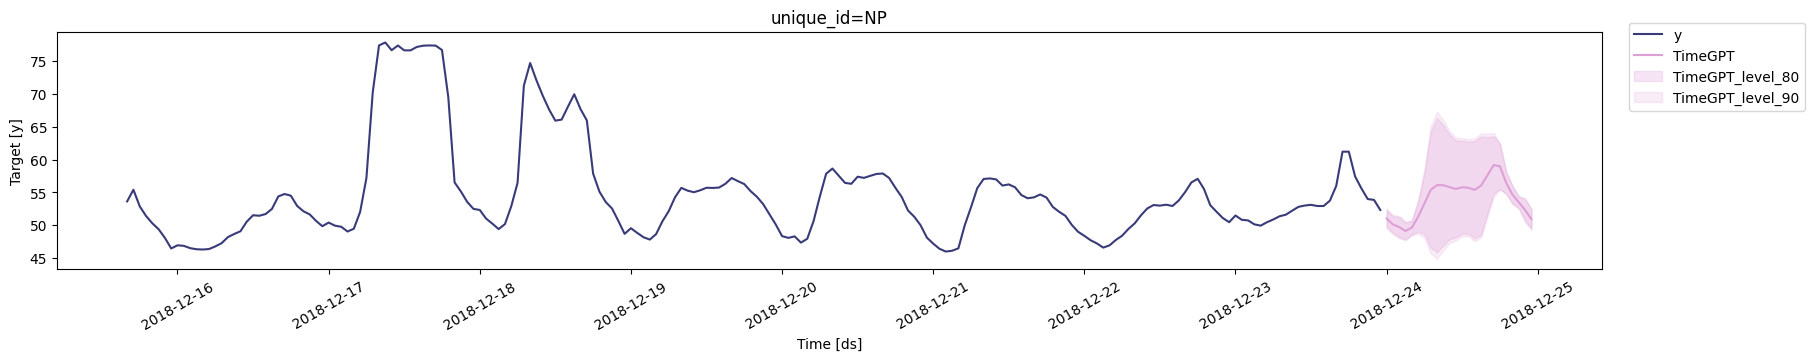

In [49]:
nixtla_client.plot(df, preds_df, level = [80, 90], max_insample_length = 200)

Next, we use cross-validation to evaluate the accuracy of the predictions the last three windows.

In [51]:
cv_preds_df = nixtla_client.cross_validation(df, freq = '1h', h = 24, n_windows = 3)
cv_preds_df.head()

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['Exogenous1', 'Exogenous2', 'day_0', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6']
INFO:nixtla.nixtla_client:Calling Cross Validation Endpoint...


unique_id,ds,cutoff,y,TimeGPT
str,datetime[μs],datetime[μs],f64,f64
"""NP""",2018-12-21 00:00:00,2018-12-20 23:00:00,47.21,47.608387
"""NP""",2018-12-21 01:00:00,2018-12-20 23:00:00,46.42,47.164246
"""NP""",2018-12-21 02:00:00,2018-12-20 23:00:00,46.0,46.52235
"""NP""",2018-12-21 03:00:00,2018-12-20 23:00:00,46.12,47.20981
"""NP""",2018-12-21 04:00:00,2018-12-20 23:00:00,46.49,47.95307


In [ ]:
eval_df = evaluate(cv_preds_df, models = ["TimeGPT"], metrics = [mae, mse, rmse])
eval_df

unique_id,metric,TimeGPT
str,str,f64
"""NP""","""mae""",1.901532
"""NP""","""mse""",8.072836
"""NP""","""rmse""",2.841274


You may also generate forecasts for longer horizons with the `timegpt-1-long-horizon` model. For example, 1 month (720h) ahead:

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


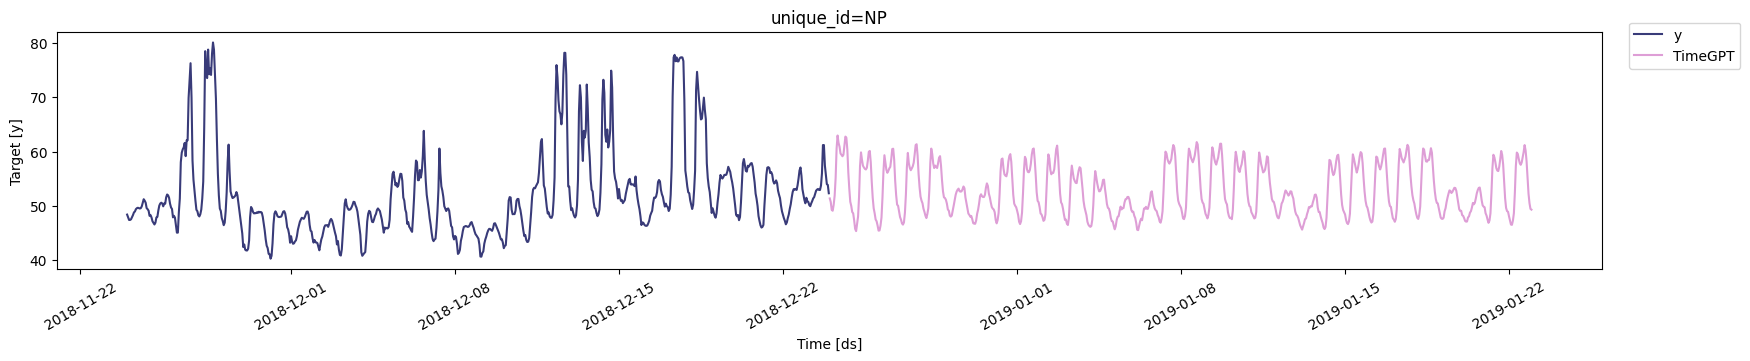

In [ ]:
preds_long_df = nixtla_client.forecast(
    df, freq = '1h', h = 720, level = [80, 90], model = 'timegpt-1-long-horizon'
)
nixtla_client.plot(df, preds_long_df, max_insample_length = 720)

## Fine-tuning

One important characteristic of foundation models is their ability to be fine-tuned to specific datasets. This can be done with TimeGPT using the `finetune_steps` argument. We can also specify the `finetune_loss` argument to optimize a specific performance metric. In the example, we optimize for the mean absolute error (MAE).

In [ ]:
cv_finetune_preds_df = nixtla_client.cross_validation(
    df, freq = '1h', h = 24, n_windows = 3, finetune_steps = 15, finetune_loss = 'mae'
)
eval_finetune_df = evaluate(cv_finetune_preds_df, models = ["TimeGPT"], metrics = [mae, mse, rmse])
eval_finetune_df

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['Exogenous1', 'Exogenous2', 'day_0', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6']
INFO:nixtla.nixtla_client:Calling Cross Validation Endpoint...


unique_id,metric,TimeGPT
str,str,f64
"""NP""","""mae""",1.889667
"""NP""","""mse""",7.965816
"""NP""","""rmse""",2.822378


## Incorporating exogenous variables

Until now, the model has used the historical values of the exogenous variables. However, it is beneficial for the model to provide the values of exogenous features over the forecast horizon. TimeGPT supports this by adding future exogenous variables to the input DataFrame. Below, we create a new DataFrame that includes the future values of the exogenous variables.

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using future exogenous features: ['Exogenous1', 'Exogenous2', 'day_0', 'day_1', 'day_2', 'day_3', 'day_4', 'day_5', 'day_6']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


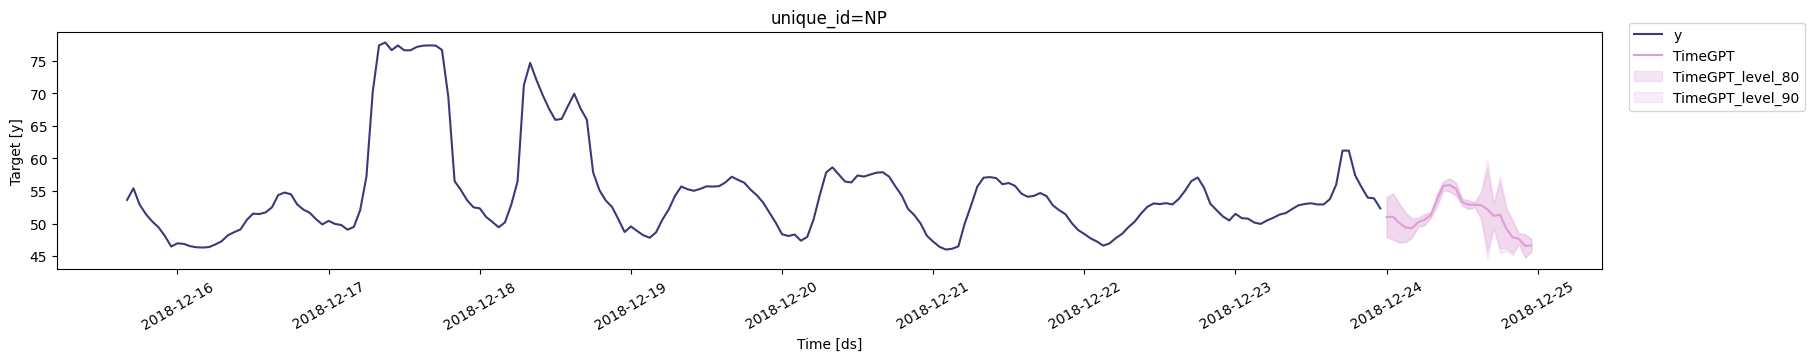

In [ ]:
future_ex_vars_df = load_data("../../data/electricity/", "electricity_future_vars", ".csv")
exog_preds_df = nixtla_client.forecast(
    df, freq = '1h', h = 24, level = [80, 90], X_df = future_ex_vars_df
)
nixtla_client.plot(df, exog_preds_df, level = [80, 90], max_insample_length = 200)

In the figure above, we can see that by using exogenous features, the model can model variations in the data that were not previously captured.

## Anomaly detection

TimeGPT can also be used for anomaly detection. The model identifies anomalies by comparing the actual values with the predicted values and their associated prediction intervals.

In [ ]:
anom_df = nixtla_client.detect_anomalies(df, freq = '1h')
anom_df
nixtla_client.plot(df, anom_df, plot_anomalies = True)

*The notebook is based on [Forecasting: Principles and Practice, the Pythonic Way](https://otexts.com/fpppy/).*